In [1]:
import numpy as np
import matplotlib.pyplot as plt
#%pip install corner
from corner import corner
import corner

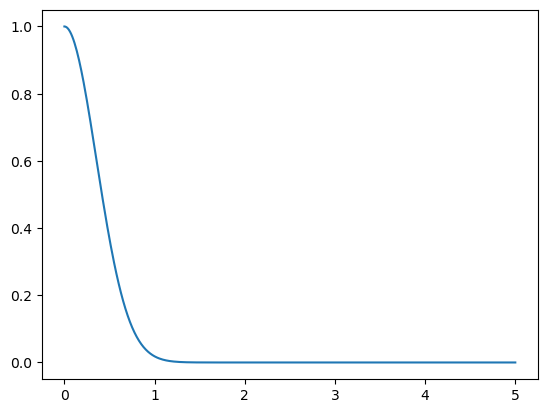

In [22]:
tau1 = 0.5
tau2 = 4
p_tau1 = 0.5
irf_width = 0.5
x = np.linspace(0,5,400)
irf = np.exp(-(x/irf_width)**2)
plt.plot(x,irf)
plt.savefig("convol/irf.svg")
plt.show()

In [3]:
def fitfun(x, pars):
    tau1_ = pars[0]
    tau2_ = pars[1]
    p_tau1_ = pars[2]
    y_raw = p_tau1_*np.exp(-x/tau1_) + (1 - p_tau1_)*np.exp(-x/tau2_)
    conv = np.real_if_close(np.fft.ifft(np.fft.fft(irf)*np.fft.fft(y_raw)))
    return conv

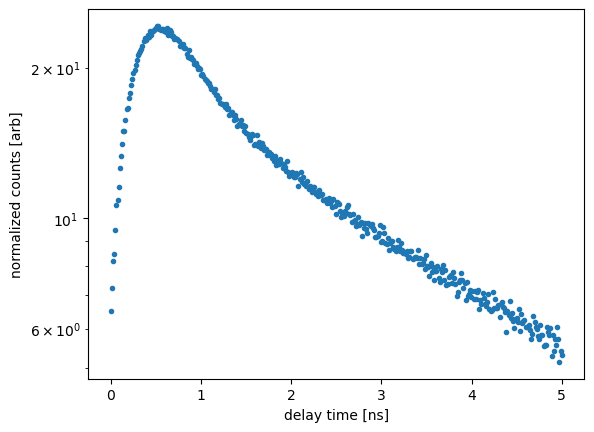

In [4]:
y = fitfun(x, [tau1, tau2, p_tau1]) + 0.2*np.random.randn(400)
err = np.sqrt(y)
#y /= np.sum(y)
plt.semilogy(x,y,".")
plt.xlabel("delay time [ns]")
plt.ylabel("normalized counts [arb]")
plt.savefig("convol/fitdata.svg")
plt.show()
def log_likelihood(X):
    tau1_ = X[0]
    tau2_ = X[1]
    p_tau1_ = X[2]
    if (tau1_<0) | (tau2_<0) | (tau1_>tau2_) | (abs(p_tau1_ - 0.5)>0.5) | (tau2_>2*np.max(x)):
        return -np.inf
    y_ = fitfun(x,X)
    f = (y - y_)/err
    return np.sum(-f**2)

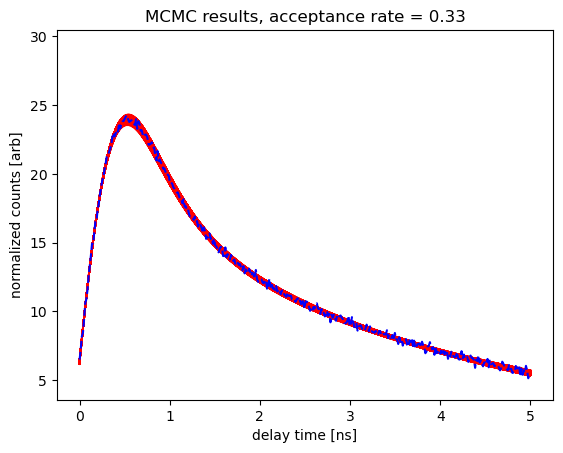

acceptance rate: 0.33137


In [18]:
init_param_guess = [1,5, 0.3]
num_reps = 100000
jump_mag = [0.05,0.1,0.01]
param_its = np.zeros((len(init_param_guess),num_reps))
param_its[:,0] = init_param_guess
rands = np.random.uniform(0,1,(num_reps))
acceptances = 0
loglikes = np.zeros_like(rands)
for i in range(num_reps-1):
    my_likelihood = log_likelihood(param_its[:,i])
    jump = jump_mag * np.random.randn(np.size(init_param_guess))
    loglikes[i] = my_likelihood
    new_params = param_its[:,i] + jump
    new_likelihood = log_likelihood(new_params)
    if rands[i] <np.exp(new_likelihood - my_likelihood):
        param_its[:,i+1] = new_params
        acceptances += 1
    else:
        param_its[:,i+1] = param_its[:,i]
    plt.plot(x,fitfun(x,param_its[:,i]),'r-', alpha = 0.2*(1+np.tanh(my_likelihood))/2)
plt.plot(x,y,'b--')
plt.xlabel("delay time [ns]")
plt.ylabel("normalized counts [arb]")
plt.title("MCMC results, acceptance rate = {}".format(round(acceptances/num_reps,2)))
plt.savefig("convol/tracks.svg")
plt.show()
print("acceptance rate: {}".format(acceptances/num_reps))


33137


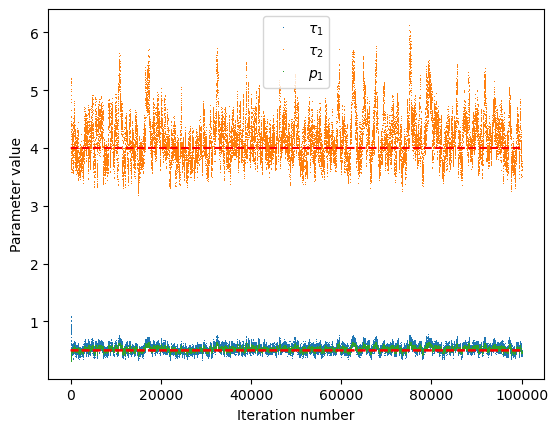

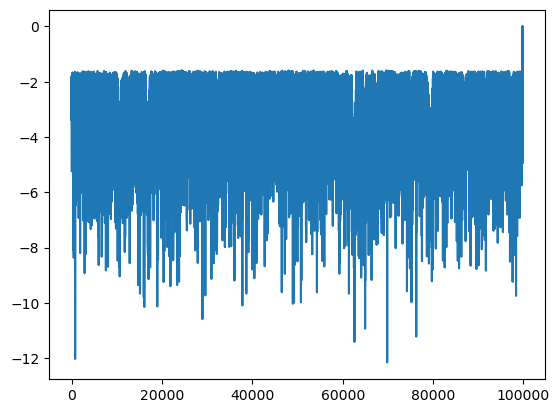

[[0.0041025  0.02058189 0.0021263 ]
 [0.02058189 0.15798974 0.01441544]
 [0.0021263  0.01441544 0.00141943]]
[0.46979415 3.75139194 0.4629641 ]


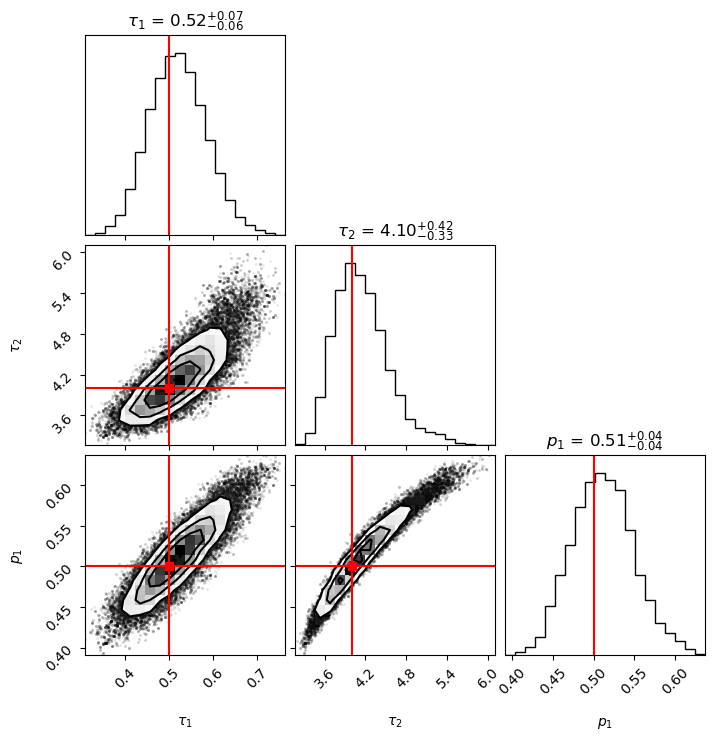

In [24]:
print(acceptances)
plt.plot(np.arange(num_reps),param_its.T,",",label = [r"$\tau_1$", r"$\tau_2$", r"$p_1$"])
plt.plot(np.arange(num_reps),np.tile(np.array([tau1,tau2,p_tau1]),(num_reps,1)),'r--')
plt.xlabel("Iteration number")
plt.ylabel("Parameter value")
plt.legend()
plt.savefig("convol/paramtracks.png",dpi = 300)
plt.show()
cutoff = 200
plt.plot(loglikes[cutoff:])
plt.show()
cor = corner.corner(param_its[:,cutoff:].T,labels = [r"$\tau_1$", r"$\tau_2$", r"$p_1$"],truths = [tau1,tau2,p_tau1],show_titles = True,truth_color = "r")
cor.savefig("convol/corner.svg")
maxlike = param_its[:,np.argmax(loglikes)]
covar = np.cov(param_its[:,cutoff:])
print(covar)
print(maxlike)
